In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (ttest_ind, f_oneway, chi2_contingency)

In [4]:
df = pd.read_csv(r'C:\Users\MOHAMMED NIHAL\OneDrive\Desktop\eda-project\data\interim\cleaned_day2.csv')
df.head()

,Row_Number,Customer_Id,Surname,Credit_Score,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Cr_Card,Is_Active_Member,Estimated_Salary,Exited,Join_Date,Last_Transaction_Date,Account_Type
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2022-09-21,2024-06-23,Savings
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,2023-01-18,2024-11-10,Current
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,2016-04-06,2023-10-21,Premium
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,2023-09-17,2024-11-18,Current
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2022-10-22,2024-11-19,Premium


# Statistical Testing

Significance Level

- For all statistical tests, a significance level (α) of 0.05 was used.

Decision Rule:

- If p-value < 0.05:
  Reject the Null Hypothesis (H₀)

- If p-value ≥ 0.05:
  Fail to Reject the Null Hypothesis (H₀)

T-Test

H0: No significant difference in balance between male and female customers.

H1: Significant difference exists.

In [5]:
male_balance = df[df['Gender'] == 'Male']['Balance']
female_balance = df[df['Gender'] == 'Female']['Balance']

t_stat, p_value = ttest_ind(
    male_balance,
    female_balance
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: 1.274674962929108
P Value: 0.20245393531015166


H0: There is no significant difference in balance between churned and non-churned customers.

H1: There is a significant difference in balance between churned and non-churned customers.

In [6]:
churned = df[df['Exited'] == 1]['Balance']
not_churned = df[df['Exited'] == 0]['Balance']

t_stat, p_value = ttest_ind(
    churned,
    not_churned
)

print('T Statistic:',round( t_stat,3))
print('P Value:',round( p_value ,3))

T Statistic: 11.315
P Value: 0.0


ANOVA

H0: Average age is the same across all account types.

H1: At least one account type has a different average age.

In [7]:
savings = df[df['Account_Type'] == 'Savings']['Age']
current = df[df['Account_Type'] == 'Current']['Age']
premium = df[df['Account_Type'] == 'Premium']['Age']

f_stat, p_value = f_oneway(
    savings,
    current,
    premium
)

print('F Statistic:', f_stat)
print('P Value:', p_value)

F Statistic: 26.453665537670325
P Value: 3.480271191812353e-12


H0: Mean balance is same across all regions.

H1: At least one region differs.

In [8]:
france = df[df['Geography'] == 'France']['Balance']
germany = df[df['Geography'] == 'Germany']['Balance']
spain = df[df['Geography'] == 'Spain']['Balance']

f_stat, p_value = f_oneway(
    france,
    germany,
    spain
)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: 843.7828120496349
P Value: 0.0


Chi-Square Test

H0: Gender and Churn are independent.

H1: Gender and Churn are associated.

In [9]:
contingency_table = pd.crosstab(df['Gender'],df['Exited'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi Square:", round(chi2 ,3))
print("P Value:", round(p_value ,3))

Chi Square: 106.048
P Value: 0.0


H0: Geography and Churn are independent.

H1: Geography and Churn are associated.

In [10]:
contingency_table = pd.crosstab( df['Geography'],df['Exited'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print('Chi Square:',round(chi2,3))
print('P Value:', round(p_value,3))

Chi Square: 290.821
P Value: 0.0


# Time-Based EDA

In [11]:
# Convert Date Columns

df['Join_Date'] = pd.to_datetime(df['Join_Date'])
df['Last_Transaction_Date'] = pd.to_datetime(df['Last_Transaction_Date'])

In [12]:
df['Join_Year'] = df['Join_Date'].dt.year
df['Join_Month'] = df['Join_Date'].dt.month_name()
df['Join_Day'] = df['Join_Date'].dt.day

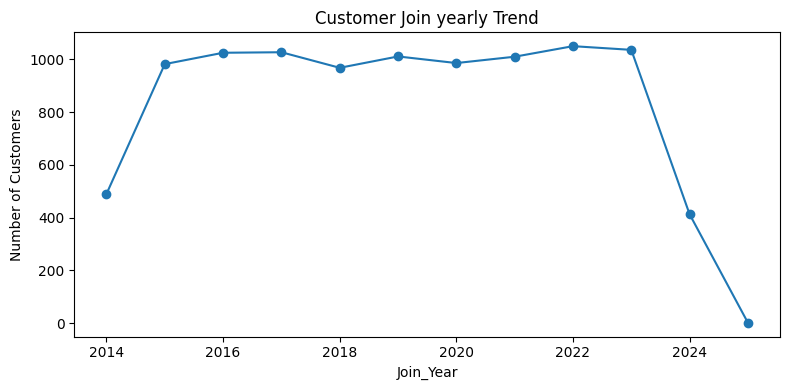

In [13]:
join_trend = (
    df['Join_Year'].value_counts().sort_index())

plt.figure(figsize=(8,4))

join_trend.plot( marker='o')
plt.title('Customer Join yearly Trend')
plt.ylabel('Number of Customers')
plt.tight_layout()

plt.savefig('../reports/figures/customer_join_yearly_trend.png')

plt.show()

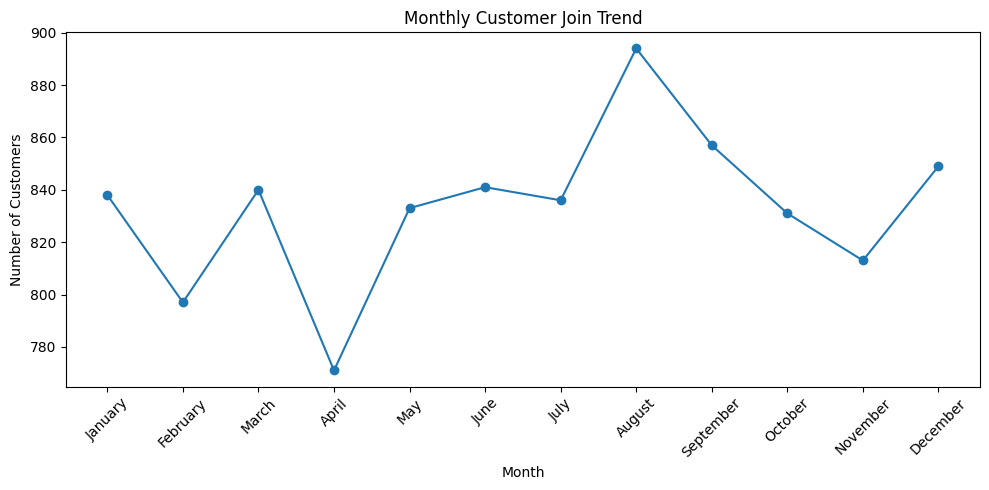

In [22]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December']

monthly_trend = (df['Join_Month'].value_counts().reindex(month_order, fill_value=0))

plt.figure(figsize=(10,5))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o')

plt.title('Monthly Customer Join Trend')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/monthly_join_trend.png')

plt.show()

# Feature Engineering

Feature 1: High Balance Customer

In [15]:
df['High_Balance'] = np.where(
    df['Balance'] > df['Balance'].median(),1,0)

df['High_Balance'].value_counts()

High_Balance
0    5225
1    4775
Name: count, dtype: int64

Feature 2: High Credit Score

In [16]:
df['High_Credit_Score'] = np.where(
    df['Credit_Score'] >= 700 , 1 , 0)

df['High_Credit_Score'].value_counts()


High_Credit_Score
0    6852
1    3148
Name: count, dtype: int64

Feature 3: Customer Relationship Duration

In [17]:
df['Customer_Age_Days'] = (
    df['Last_Transaction_Date'] -df['Join_Date']).dt.days

df.head()

,Row_Number,Customer_Id,Surname,Credit_Score,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,...,Exited,Join_Date,Last_Transaction_Date,Account_Type,Join_Year,Join_Month,Join_Day,High_Balance,High_Credit_Score,Customer_Age_Days
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,...,1,2022-09-21,2024-06-23,Savings,2022,September,21,0,0,641
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,...,0,2023-01-18,2024-11-10,Current,2023,January,18,0,0,662
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,...,1,2016-04-06,2023-10-21,Premium,2016,April,6,1,0,2754
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,...,0,2023-09-17,2024-11-18,Current,2023,September,17,0,0,428
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,...,0,2022-10-22,2024-11-19,Premium,2022,October,22,1,1,759


Feature 4: Long-Term Customer

In [18]:
df['Long_Term_Customer'] = np.where(
    df['Tenure'] >= 5,'Yes','No')

df['Long_Term_Customer'].value_counts()

Long_Term_Customer
Yes    5506
No     4494
Name: count, dtype: int64

Feature 5: Credit Score Category

In [19]:
df['Credit_Category'] = pd.cut(
    df['Credit_Score'],bins=[300, 580, 670, 740, 850],labels=['Poor', 'Fair', 'Good', 'Excellent'])

df['Credit_Category'].value_counts()

Credit_Category
Fair         3350
Good         2397
Poor         2393
Excellent    1860
Name: count, dtype: int64

In [20]:
df[['High_Balance',
    'High_Credit_Score',
    'Customer_Age_Days',
    'Long_Term_Customer',
    'Credit_Category']].head()

,High_Balance,High_Credit_Score,Customer_Age_Days,Long_Term_Customer,Credit_Category
0,0,0,641,No,Fair
1,0,0,662,No,Fair
2,1,0,2754,Yes,Poor
3,0,0,428,No,Good
4,1,1,759,No,Excellent


In [21]:
df.to_csv('../data/processed/final_cleaned_day4.csv',index=False)

Top 10 Insights


- Approximately 20% of customers have churned, while 80% remain with the bank.
- Customer churn is significantly associated with geography.
- Germany shows the highest churn rate among all regions.
- Customer balance differs significantly between churned and non-churned customers.
- Most customers fall within the 30–45 age group.
- Customers aged 51–60 show relatively higher churn compared to younger age groups.
- Most customers hold Current accounts, making it the dominant account type.
- The majority of customers possess a credit card.
- Balance and number of products show a moderate negative correlation (-0.29).
- Customer acquisition remains relatively stable throughout the years with minor seasonal fluctuations.

Segment Findings

- Geography Segment
France contains the largest customer base.
Germany has the highest churn proportion.
Average balances are highest among German customers.

- Age Group Segment
Customers aged 31–40 form the largest segment.
Customers aged 51–60 exhibit the highest churn tendency.

- Account Type Segment
Current accounts are the most popular.
Premium account holders show relatively higher churn counts than Savings customers.

- Gender Segment
Male customers slightly outnumber female customers.
Statistical testing indicates a significant association between gender and churn.

- Customer Tenure Segment
More than half of customers are long-term customers (Tenure ≥ 5 years).
Long-term customers represent a valuable retention segment.